In [1]:
from __future__ import annotations

import os
import pickle
import networkx as nx
import numpy as np

from typing import TypedDict, List, Dict

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langgraph.graph import StateGraph, START, END

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatOllama(model="deepseek-v3.1:671b-cloud")
embedder = OllamaEmbeddings(model="nomic-embed-text")

In [3]:
class LightRAGState(TypedDict):
    query: str

    graph: nx.Graph
    kv_store: Dict[str, str]

    low_keywords: List[str]
    high_keywords: List[str]

    retrieved_nodes: List[str]
    context: str

    answer: str

In [ ]:
def build_graph_index(pdf_path, save_path="graph_index.pkl"):
    print("📥 Loading PDF...")
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=5000,
        chunk_overlap=1000
    )
    chunks = splitter.split_documents(docs)

    G = nx.Graph()
    kv_store = {}

    print("⚙️ Building Knowledge Graph...")

    for chunk in chunks:  # limit for demo
        text = chunk.page_content

        triples = llm.invoke(f"""
        Extract triples in format:
        (subject, relation, object)

        TEXT:
        {text}
        """).content

        for line in triples.split("\n"):
            if "(" in line and "," in line:
                try:
                    s, r, o = [x.strip() for x in line.strip("()").split(",")]

                    G.add_node(s)
                    G.add_node(o)
                    G.add_edge(s, o, relation=r)

                    # KV MEMORY
                    if s not in kv_store:
                        kv_store[s] = llm.invoke(f"""
                        Summarize entity:
                        {s}
                        """).content

                    if o not in kv_store:
                        kv_store[o] = llm.invoke(f"""
                        Summarize entity:
                        {o}
                        """).content

                except:
                    continue

    # SAVE GRAPH
    with open(save_path, "wb") as f:
        pickle.dump((G, kv_store), f)

    print("✅ Graph saved to disk")

In [5]:
def load_graph_index(path="graph_index.pkl"):
    if not os.path.exists(path):
        raise ValueError("❌ Graph not built yet. Run build_graph_index() first.")

    with open(path, "rb") as f:
        G, kv_store = pickle.load(f)

    print("✅ Graph loaded (no recomputation)")
    return G, kv_store

In [6]:
def extract_keywords(state: LightRAGState):
    result = llm.invoke(f"""
    Extract keywords in JSON:

    Query: {state['query']}

    {{
      "low_level_keywords": [],
      "high_level_keywords": []
    }}
    """).content

    import json
    try:
        data = json.loads(result)
        return {
            "low_keywords": data["low_level_keywords"],
            "high_keywords": data["high_level_keywords"]
        }
    except:
        return {"low_keywords": [], "high_keywords": []}

In [7]:
def retrieve_nodes(state: LightRAGState):
    G = state["graph"]
    nodes = list(G.nodes)

    node_emb = embedder.embed_documents(nodes)

    selected = set()

    # LOW LEVEL
    for kw in state["low_keywords"]:
        kw_emb = embedder.embed_query(kw)

        sims = [
            np.dot(kw_emb, node_emb[i]) /
            (np.linalg.norm(kw_emb) * np.linalg.norm(node_emb[i]))
            for i in range(len(nodes))
        ]

        best = nodes[int(np.argmax(sims))]
        selected.add(best)

    # HIGH LEVEL → expand graph
    for node in list(selected):
        neighbors = list(G.neighbors(node))
        selected.update(neighbors)

    return {"retrieved_nodes": list(selected)}

In [8]:
def build_context(state: LightRAGState):
    kv_store = state["kv_store"]

    context = "\n\n".join([
        kv_store.get(node, "")
        for node in state["retrieved_nodes"]
    ])

    return {"context": context}

In [9]:
def generate_answer(state: LightRAGState):
    answer = llm.invoke(f"""
    Answer using context.

    QUERY:
    {state['query']}

    CONTEXT:
    {state['context']}
    """).content

    return {"answer": answer}

In [10]:
def build_query_pipeline():
    builder = StateGraph(LightRAGState)

    builder.add_node("extract_keywords", extract_keywords)
    builder.add_node("retrieve", retrieve_nodes)
    builder.add_node("context", build_context)
    builder.add_node("generate", generate_answer)

    builder.add_edge(START, "extract_keywords")
    builder.add_edge("extract_keywords", "retrieve")
    builder.add_edge("retrieve", "context")
    builder.add_edge("context", "generate")
    builder.add_edge("generate", END)

    return builder.compile()

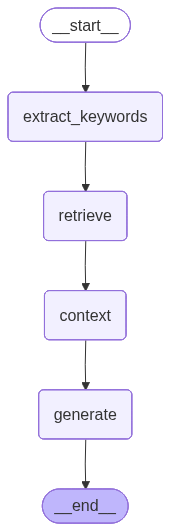

In [11]:
app=build_query_pipeline()
app

In [12]:
if __name__ == "__main__":

    pdf_path = "D:/Capstone/capstone_proposal.pdf"

    # =========================
    # RUN ONLY FIRST TIME
    # =========================
    if not os.path.exists("graph_index.pkl"):
        build_graph_index(pdf_path)

    # =========================
    # LOAD GRAPH (FAST)
    # =========================
    G, kv_store = load_graph_index()

    app = build_query_pipeline()

    print("\n⚡ LightRAG Ready (Graph reused)\n")

    while True:
        query = input("👉 Ask: ")

        if query.lower() == "exit":
            break

        result = app.invoke({
            "query": query,
            "graph": G,
            "kv_store": kv_store
        })

        print("\n✅ ANSWER:\n")
        print(result["answer"])
        print("\n" + "="*60)

📥 Loading PDF...
⚙️ Building Knowledge Graph...
✅ Graph saved to disk
✅ Graph loaded (no recomputation)

⚡ LightRAG Ready (Graph reused)


✅ ANSWER:

Hello! It looks like your query is a simple greeting. How can I help you today? If you have any questions about the provided context on Hybrid RAG, systems, or multimodal interaction, feel free to ask.


✅ ANSWER:

Based on the provided context, there is no information available to answer your query about a "multimodel agent." The context is empty.

To get an accurate answer, please provide the relevant text or documents that discuss this topic.


✅ ANSWER:

Based on the provided context, a **multi-agent conversational AI tutor system** would be a sophisticated educational platform that leverages multiple AI agents working together through conversation to deliver personalized learning.

Here is a synthesis of its key characteristics derived from the context:

*   **Core Function:** It is an **AI tutor system** (Intelligent Tutoring System